# 260902
[SQL chapter01]

---

## 1. Key Concepts

- erd cloud 
- DBeaver
- Docker 이용해서 postgre 설치

| 용어 | 정의 |
|---|---|
| **Data** | • 정제되지 않은(맥락의 의미가 부여되지 않은) 정보 혹은 그러한 정보의 더미 |
| **Database** | • 데이터들이 구조화된 집합 |
| **DBMS** | • DataBase Management System<br>• 데이터를 관리하는 소프트웨어 |
| **Query** | • 데이터베이스에서 원하는 데이터를 검색/추출하기 위한 ‘질문’ 또는 ‘명령’ |
| **SQL** | • Structured Query Language<br>- structured: 정해진 문법과 구조를 가진<br> - Query: 데이터베이스에 데이터를 요청하는 질의 <br>- Language: 데이터베이스와 상호작용하기 위한 언어<br>• **Why “Structured”?**<br>→ RDBMS에서 데이터를 **정해진 구조(테이블, 행, 열 등)**에 따라 다루기 때문 |

- RDBMS: table간 "관계" 명시, 관계 바탕으로 데이터 설계되는 형태의 데이터
- schema: 테이블 구조와 제약사항을 정리

| DBMS | 주요 특징 | 주요 사용처 |
|---|---|---|
| **MySQL** | • 오픈소스 관계형 데이터베이스(RDBMS)<br>• 다중 사용자 및 다중 스레드 지원<br>• 표준 SQL 사용<br>• 비교적 사용과 관리가 쉬움 | • 웹서비스<br>• 스타트업<br>• 일반적인 웹 애플리케이션 |
| **PostgreSQL** | • 오픈소스 객체-관계형 데이터베이스(ORDBMS)<br>• SQL 표준 준수 수준이 높음<br>• 복잡한 쿼리와 대용량 데이터 처리에 강함<br>• 사용자 정의 타입, 함수, 연산자 등 확장성이 높음<br>• 테이블 상속 지원<br>• **PostGIS**를 통한 강력한 지리정보(GIS) 기능 지원 | • 데이터 분석<br>• 금융/엔터프라이즈 시스템<br>• GIS<br>• 복잡한 비즈니스 로직이 필요한 서비스 |
| **Oracle Database** | • 대표적인 상용 관계형 데이터베이스(RDBMS)<br>• 대규모 데이터와 기업용 시스템에 적합<br>• 높은 안정성 및 고가용성 지원<br>• Oracle 고유 기능 및 SQL 확장 기능 제공 | • 대기업 핵심 시스템<br>• 은행/금융 시스템<br>• 공공기관<br>• 대규모 엔터프라이즈 시스템 |
| **MS SQL Server** | • Microsoft에서 개발한 관계형 데이터베이스(RDBMS)<br>• Windows 및 Microsoft 생태계와 높은 호환성<br>• GUI 기반 관리 도구 제공<br>• .NET 및 Azure 등 Microsoft 기술과 연계가 용이 | • Windows 기반 기업 환경<br>• ERP 시스템<br>• 사내 시스템<br>• 엔터프라이즈 애플리케이션 |
| **MongoDB** | • 오픈소스 문서 지향 NoSQL 데이터베이스<br>• 데이터를 BSON(Document) 형태로 저장<br>• 고정된 테이블 스키마가 필수적이지 않아 유연한 데이터 구조 지원<br>• 수평적 확장에 유리 | • 콘텐츠 관리(CMS)<br>• 로그 및 이벤트 데이터<br>• 실시간 애플리케이션<br>• 빠르게 변화하는 비정형/반정형 데이터 |
| **Cassandra** | • 분산형 NoSQL 데이터베이스<br>• 대규모 데이터의 높은 쓰기 성능과 가용성에 강함<br>• 서버를 중단하지 않고 수평적 확장 가능<br>• 여러 노드에 데이터를 분산 저장 | • IoT 센서 데이터<br>• 대규모 로그 데이터<br>• 시계열 데이터<br>• 글로벌 대규모 서비스 인프라 |
| **Redis** | • Remote Dictionary Server<br>• 오픈소스 **In-memory 데이터 저장소**<br>• Key-Value 기반으로 동작<br>• 데이터를 메모리에 저장하여 매우 빠른 읽기/쓰기 가능<br>• String, List, Hash, Set, Sorted Set 등 다양한 자료구조 지원<br>• 캐시, 세션, 메시징 등 다양한 용도로 활용 | • 웹/모바일 애플리케이션<br>• 캐시<br>• 세션 관리<br>• 실시간 랭킹<br>• 메시지 큐/스트리밍<br>• 실시간 데이터 처리 |

Mongo, Cassandra, Redis -> RDBMS X

데이터 무결성 제약조건
| 무결성 제약조건    | 정의                                               | 핵심 내용                                                | 예시                                     |
| ----------- | ------------------------------------------------ | ---------------------------------------------------- | -------------------------------------- |
| **도메인 무결성** | 컬럼에 저장되는 값이 **정해진 도메인(자료형, 범위, 형식 등)**을 만족하도록 보장 | 컬럼의 자료형, `CHECK`, `NOT NULL` 등으로 잘못된 값의 입력을 제한       | `age INT`, `age CHECK (age >= 0)`      |
| **개체 무결성**  | 테이블의 각 행(Row)을 **고유하게 식별**할 수 있도록 보장             | **PRIMARY KEY는 중복될 수 없고 `NULL`일 수 없음**               | `member_id PRIMARY KEY`                |
| **참조 무결성**  | 서로 관계가 있는 테이블 간의 **데이터 일관성**을 보장                 | **FOREIGN KEY가 참조하는 값은 부모 테이블의 PK/UNIQUE 값에 존재해야 함** | `orders.member_id → members.member_id` |


# Data Type (자료형)

| 분류 | 자료형 | 크기 / 형식 | 설명 | 예시 |
|---|---|---|---|---|
| 숫자형 | `SMALLINT` | 2 bytes | 작은 범위의 정수 | `100` |
| 숫자형 | `INT` / `INTEGER` | 4 bytes | 일반적인 정수 | `10000` |
| 숫자형 | `BIGINT` | 8 bytes | 큰 범위의 정수 | `10000000000` |
| 숫자형 | `REAL` | 4 bytes | 단정밀도 부동소수점 | `3.14` |
| 숫자형 | `DOUBLE PRECISION` | 8 bytes | 배정밀도 부동소수점 | `3.141592` |
| 숫자형 | `DECIMAL(p, s)` / `NUMERIC(p, s)` | `p, s` | 정확한 소수점 계산이 필요한 숫자<br>• `p`: 전체 자릿수<br>• `s`: 소수점 이하 자릿수 | `DECIMAL(10, 2)` |
| 문자형 | `CHAR(n)` | 고정 길이 | 고정된 길이의 문자열 | `'M'`, `'F'` |
| 문자형 | `VARCHAR(n)` | 최대 `n`자 | 최대 길이가 `n`인 가변 길이 문자열 | `'Myungji'` |
| 문자형 | `TEXT` | 가변 길이 | 길이 제한이 사실상 없는 가변 문자열 | `'Hello World'` |
| 논리형 | `BOOLEAN` | 1 byte | 참/거짓/NULL 저장 | `TRUE`, `FALSE` |
| 날짜/시간 | `DATE` | 날짜 | 날짜만 저장 | `2026-09-02` |
| 날짜/시간 | `TIME` | 시간 | 시간만 저장 | `14:30:00` |
| 날짜/시간 | `TIMESTAMP` | 날짜 + 시간 | 날짜와 시간을 저장 | `2026-09-02 14:30:00` |
| 날짜/시간 | `TIMESTAMPTZ` | 날짜 + 시간 + 시간대 | 시간대 정보를 고려하여 시각을 저장 | `2026-09-02 14:30:00+09` |
| JSON | `JSON` | - | JSON 데이터를 원본 텍스트 형태로 저장 | `'{"name":"Lee"}'` |
| JSON | `JSONB` | Binary | JSON을 Binary 형태로 저장하여 검색/연산에 유리 | `'{"name":"Lee"}'` |
| 기타 | `ENUM` | 정해진 값 | 미리 정의된 값 중 하나만 저장 | `READY`, `ORDER` |
| 기타 | `VECTOR(n)` | `n`차원 | 벡터 데이터를 저장 (pgvector 확장) | `vector(1536)` |

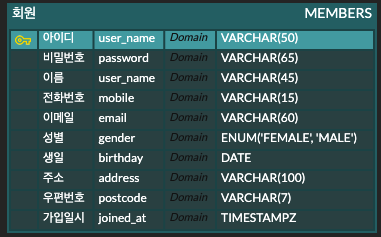

--> erd cloud에서 실습

gender와 같이 정확한 문자열이 들어와야 하는 데이터는 enum으로 지정하여 잘못된 문자열이 들어오는 것을 막는다.

primary key - 기본키
- 특징: unique, not null, 대표 컬럼

--- 
## 2. Daily Quest

틀린 문제
> 관계형 데이터베이스(RDBMS)가 계층형·망형 데이터베이스와 비교하여 갖는 특징으로 가장 적절한 것은?

- 오답: A. 데이터를 트리 구조로 저장하여 부모-자식 간 상하 관계가 명확하다
- 해설: 관계형(RDBMS)은 테이블 형태로 데이터를 저장하여 유연성이 높고 SQL로 조회 가능하다는 특징이 있습니다. 첫 번째는 계층형(HDBMS), 두 번째는 망형(NDBMS)의 특징이며, 네 번째는 SQLite와 같은 파일 기반 DB의 특징으로 RDBMS 전체를 설명하지 않습니다.